In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [6]:
df_raw = pd.read_csv("historico_parking.csv")

parkings_totales = df_raw['nombre'].unique()
anomalos_conexion = df_raw[df_raw['plazas_libres'] == -1]
anomalos_cerrados = df_raw[df_raw['plazas_libres'] == -2]
anomalos_capacidad = df_raw[df_raw['capacidad'] <= 0]
exceso_plazas = df_raw[(df_raw['plazas_libres'] > df_raw['capacidad']) & (df_raw['plazas_libres'] > 0)]

print("Total registros:", df_raw.shape[0])
print("Total parkings distintos:", len(parkings_totales))
print("Sensores sin conexión (-1):", len(anomalos_conexion))
print("Parkings cerrados (-2):", len(anomalos_cerrados))
print("Errores de capacidad (<= 0):", len(anomalos_capacidad))
print("Anomalía lógica (Libres > Capacidad):", len(exceso_plazas))

Total registros: 4715
Total parkings distintos: 23
Sensores sin conexión (-1): 1845
Parkings cerrados (-2): 820
Errores de capacidad (<= 0): 0
Anomalía lógica (Libres > Capacidad): 5


In [7]:
df = df_raw[
    (df_raw['plazas_libres'] >= 0)
    & (df_raw['capacidad'] > 0)
    & (df_raw['plazas_libres'] <= df_raw['capacidad'])].copy()

df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])
df['hora'] = df['fecha_registro'].dt.hour
df['dia_semana'] = df['fecha_registro'].dt.day_name()
df['ocupacion_pct'] = ((df['capacidad'] - df['plazas_libres']) / df['capacidad']) * 100

print(f"Filas tras limpieza: {len(df)} (de {len(df_raw)} originales)")
print(f"Parkings monitorizados: {df['nombre'].nunique()}")

Filas tras limpieza: 2045 (de 4715 originales)
Parkings monitorizados: 10


In [13]:
X = pd.get_dummies(df[['nombre', 'dia_semana', 'hora']], columns=['nombre', 'dia_semana'])
y = df['ocupacion_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelos = {
    "Regresión Lineal": LinearRegression(),
    "KNN (K-Nearest)": KNeighborsRegressor(n_neighbors=5),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "SVM (Soporte Vectorial)": SVR(kernel='linear'),
    "Red Neuronal (MLP)": MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)}

resultados = {}
for nombre_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    resultados[nombre_modelo] = {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)}

print("COMPETICIÓN DE MODELOS (TEST SET):")
for nombre_modelo, metricas in resultados.items():
    print(f"{nombre_modelo} -> R2: {metricas['R2']:.4f} | MAE: {metricas['MAE']:.2f}%")

COMPETICIÓN DE MODELOS (TEST SET):
Regresión Lineal -> R2: 0.6833 | MAE: 13.84%
KNN (K-Nearest) -> R2: 0.6687 | MAE: 14.36%
Árbol de Decisión -> R2: 0.8565 | MAE: 5.71%
Random Forest -> R2: 0.8789 | MAE: 5.52%
SVM (Soporte Vectorial) -> R2: 0.6687 | MAE: 12.29%
Red Neuronal (MLP) -> R2: 0.8166 | MAE: 10.12%


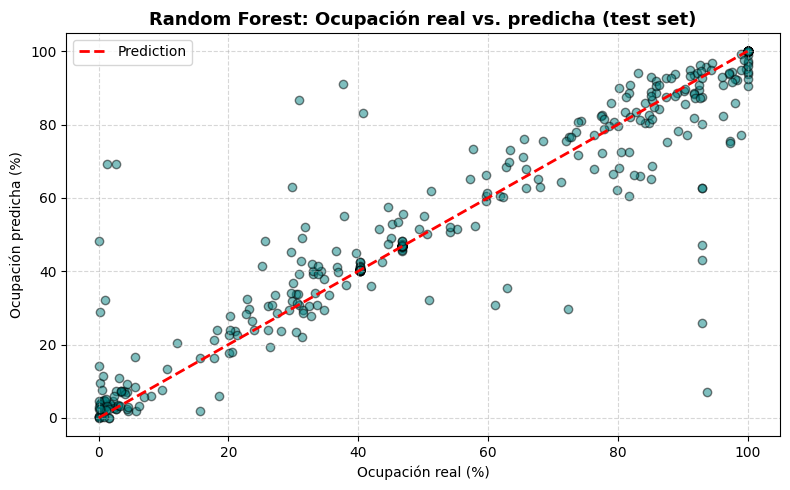

In [14]:
modelo_rf_base = modelos["Random Forest"]
y_pred_rf = modelo_rf_base.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal', edgecolor='k')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=2, label='Prediction')
plt.title('Random Forest: Ocupación real vs. predicha (test set)', fontsize=13, fontweight='bold')
plt.xlabel('Ocupación real (%)')
plt.ylabel('Ocupación predicha (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
GAP_MAXIMO_HORAS = 6  # not taking into account more than 6 hours difference

df_modelo = df.sort_values(['nombre', 'fecha_registro']).copy()
df_modelo['ocup_actual'] = df_modelo.groupby('nombre')['ocupacion_pct'].shift(1)
df_modelo['fecha_anterior'] = df_modelo.groupby('nombre')['fecha_registro'].shift(1)
df_modelo['gap_horas'] = (df_modelo['fecha_registro'] - df_modelo['fecha_anterior']).dt.total_seconds() / 3600.0

df_modelo = df_modelo.dropna(subset=['ocup_actual', 'gap_horas'])
df_modelo = df_modelo[df_modelo['gap_horas'] <= GAP_MAXIMO_HORAS].copy()
df_modelo = df_modelo.sort_values('fecha_registro').reset_index(drop=True)

print(f"Filas utilizables (con lectura previa real, gap <= {GAP_MAXIMO_HORAS}h): {len(df_modelo)}")


corte = int(len(df_modelo) * 0.8)
train_final = df_modelo.iloc[:corte]
test_final = df_modelo.iloc[corte:]

cols_final = ['nombre', 'dia_semana', 'hora', 'ocup_actual']
X_train_final = pd.get_dummies(train_final[cols_final], columns=['nombre', 'dia_semana'])
X_test_final = pd.get_dummies(test_final[cols_final], columns=['nombre', 'dia_semana'])
X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)

y_train_final = train_final['ocupacion_pct']
y_test_final = test_final['ocupacion_pct']

modelo_final = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
modelo_final.fit(X_train_final, y_train_final)

pred_train_final = modelo_final.predict(X_train_final)
pred_test_final = modelo_final.predict(X_test_final)

print("--- RESULTADOS MODELO FINAL ---")
print(f"R² Train: {r2_score(y_train_final, pred_train_final):.4f}  |  MAE Train: {mean_absolute_error(y_train_final, pred_train_final):.2f}%")
print(f"R² Test:  {r2_score(y_test_final, pred_test_final):.4f}  |  MAE Test:  {mean_absolute_error(y_test_final, pred_test_final):.2f}%")

importancias = pd.Series(modelo_final.feature_importances_, index=X_train_final.columns)
importancias = importancias.sort_values(ascending=False)

print("--- IMPORTANCIA DE FEATURES (top 10) ---")
print(importancias.head(10).round(4).to_string())
print(f"\n'ocup_actual' representa el {importancias.get('ocup_actual', 0.0):.1%} de la importancia total.")

Filas utilizables (con lectura previa real, gap <= 6h): 2002
--- RESULTADOS MODELO FINAL ---
R² Train: 0.9881  |  MAE Train: 1.77%
R² Test:  0.9054  |  MAE Test:  4.71%
--- IMPORTANCIA DE FEATURES (top 10) ---
ocup_actual                       0.7995
hora                              0.0952
nombre_SEVERO OCHOA               0.0178
nombre_RUZAFA                     0.0141
nombre_PORTA DE LA MAR - COLON    0.0126
nombre_REINO DE VALENCIA          0.0094
nombre_ROIG ARENA                 0.0079
nombre_PROFESOR TIERNO GALVÁN     0.0063
nombre_GLORIETA - PAZ             0.0051
dia_semana_Saturday               0.0049

'ocup_actual' representa el 79.9% de la importancia total.
